# Example 3.0 - Single Notebook Workflow for XAS Data Processing

    This example uses all functions in Examples 2.0, 2.1, 2.3, 2.4, and 2.5 to import XAS and process data, calibrate the XAS, normalize the XANES, correlate the XAS and process data, perform a simple LCF analysis on the XANES spectra, and save the key results. 
    
    It is the basis for a standard analysis using the catXAS Experiment Class.
    
    This example does not cover EXAFS extraction, but the functions from Example 2.2 can be readily incorporated.

## Step 1. Import Modules

In [1]:
# File Handling
import os
import pickle

# Plot Handling
import matplotlib.pyplot as plt

# data handling
import numpy as np
import pandas as pd

# Make things interactive
import ipywidgets as widgets
from ipywidgets import interact, fixed, GridspecLayout
from IPython.display import display

# catXAS Handling:
os.chdir('..')
pwd = os.getcwd()
os.chdir('./catxas')
import general as fcts
import xas as xfcts
import plot as pfcts
import process
import experiment as exp

%matplotlib inline

## Step 2. Definitions

In [2]:
# Data Location Definitions:

# Folder containing ONLY XAS spectra
data_dir = os.path.join(pwd, 'sample data\Raw Data')

# Scan naame of one of the XAS spectra - used for inspection of the experiment groups
scan_name = r'20210614_SnO2_H2_TPR_Sn_EXAFS_92.tra_0001'

# Mass Spec File (full path):
MS_filename = os.path.join(pwd, 'sample data\SnO2_TPR_MS.csv') 

# AmP LabView File (full path):
LV_filename = os.path.join(pwd, 'sample data\SnO2_TPR_LV.txt')

In [3]:
# Output Definitions: 

# Unique name for the experiment
exp_name = 'SnO2_TPR'

# Directory where to save the experiment:
pickle_dir = os.path.join(pwd, 'sample results')

# File name to save the sxperiment (must include extension '.pickle')
pickle_name = exp_name+'.pickle'

# Folder where results will be saved
output_dir = os.path.join(pwd, 'sample results')

# File name for saving spectra-process correlation data (extension can be left blank or .csv/.txt)
fname_correlation = exp_name+'_Process_Correlation'

# File name to save normalized and interpolated XAS spectra
fname_interpXAS = exp_name+'_NormXANES'

In [4]:
# Plotting Defs

Edge_Energy = 29200 # eV

emin = Edge_Energy-50 # eV

emax = Edge_Energy+50 # eV

## Step 3. Define Beamline Data Structure

Common data formats for SSRL beamlines can be found in the "BL specific XAS data structures.ipynb" notebook.

In [5]:
### Define the layout of the xas data file and how spectra are calcualted
xas_data_structure = {
    'time stamp': True,
    'time on line': 5,
    'time format': '# This Scan Create Date:\t%m/%d/%Y %I:%M:%S %p',
    'padded scan numbers': True,
    'column names': ['encoder', 'energy', 'adc_01', 'adc_02', 'adc_03', 'adc_04', 'adc_05', 'adc_06', 'adc_07', 'adc_08'],
    'energy column' : 'energy', # Energy [eV]
    'sample numerator': 'adc_01', # I0
    'sample denominator': 'adc_02', # I1
    'sample ln': True,
    'sample invert': False,
    'reference numerator': 'adc_02', # I1
    'reference denominator': 'adc_03', # I2
    'reference ln': True,
    'reference invert': False,
    'is QEXAFS': False
}

## Step 4. Add Data to Experiment Object

In [6]:
# Create the Experimental Class
my_exp = exp.Experiment(exp_name)

# Add raw data into spectra files
my_exp.import_spectra(data_dir, xas_data_structure, ext = '.txt', print_name = False)

# Sanity Check to confirm data was imported
my_exp.summary['XAS Spectra Files']

## Step 5. Clean up Data
    
#### STILL IN DEVELOPMENT

In [10]:
my_exp.organize_RawData(remove_duplicates=True, remove_nan_inf=False, remove_zeros=False, feedback=False, summary=True) # remove_nan_inf & remove_zeros does not work yet

Data Organized
Range of data points per raw spectra: 4980-4980
Range of data points after duplicates removed: 4838-4839
Range of data points after NaN/inf removed: 4980-4980
Range of data points after zeros removed: 4980-4980


## Step 6. Calculate Absorption Spectra

In [11]:
# Calcualte mux for Sample:
sample_spectra = True

# Calcualte mux for Reference:
ref_spectra = True

# Calculate Absorptoin Spectra
my_exp.calculate_spectra(sample_spectra = sample_spectra, ref_spectra = ref_spectra)

# Visualize absorption spectra of the sample and reference for scan_name.

Samp_group = my_exp.spectra[scan_name]['Absorption Spectra']['mu Sample']
Ref_group = my_exp.spectra[scan_name]['Absorption Spectra']['mu Reference']

pfcts.plot_XANES([Samp_group, Ref_group], emin, emax, spectra = 'mu',  
                 e0 = None, e0_line = False, ref_lines = [emin+5, emax-5], 
                 deriv = True, overlay = False,
                 filtering = True, window_length = 21, polyorder = 4)

## Step 7. Calibrate Energy and Find E0

### Reference Edge Calibration + E0 determination

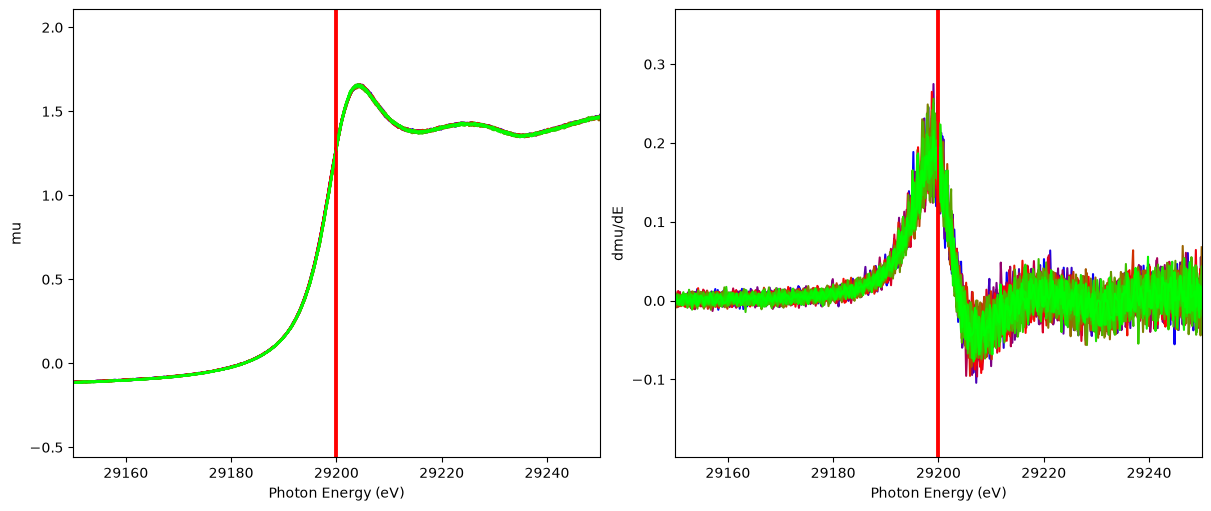

interactive(children=(FloatSlider(value=29200.0, description='ref_lines', max=29250.0, min=29150.0, step=0.05)…

<function ipywidgets.widgets.interaction._InteractFactory.__call__.<locals>.<lambda>(*args, **kwargs)>

In [13]:
# Option 2a: Manual edge calibration - Find the Edge

samp_ref = 'mu Reference'
spectra = 'mu'
deriv = True
e0 = None
e0_line = False 
ref_lines = (emin, emax, 0.05)
overlay = True
use_legend = False
cmap_name = 'brg'
filtering = False
window_length = 31
polyorder = 4

# Reset delE
delE_params = {'delE': 0,
              'e0': None}

# Sample
my_exp.load_params('mu Sample', delE_params)

# Reference
my_exp.load_params('mu Reference', delE_params)

interact(my_exp.plot_XANES_spectra,
         emin = fixed(emin),
         emax = fixed(emax),
         samp_ref = fixed(samp_ref),
         spectra = fixed(spectra),
         deriv = fixed(deriv),
         e0 = fixed(e0),
         e0_line = fixed(e0_line),
         ref_lines = ref_lines,
         overlay = fixed(overlay),
         use_legend = fixed(use_legend),
         cmap_name = fixed(cmap_name),
         filtering = fixed(filtering),
         window_length = fixed(window_length),
         polyorder = fixed(polyorder))

In [14]:
# Option 2b: Manual edge calibration - Apply del E and E0

# Modify as needed:

found_edge = 29199.0

# DO NOT NEED TO MODIFY BELOW
delE = Edge_Energy-found_edge

ref_edge_params = {'delE': delE,
                   'e0': Edge_Energy}

samp_edge_params = {'delE': delE}

# Sample
my_exp.load_params('mu Sample', samp_edge_params)

# Reference
my_exp.load_params('mu Reference', ref_edge_params)

print(f'delE parameter: {delE:0.2f}')

delE parameter: 1.00


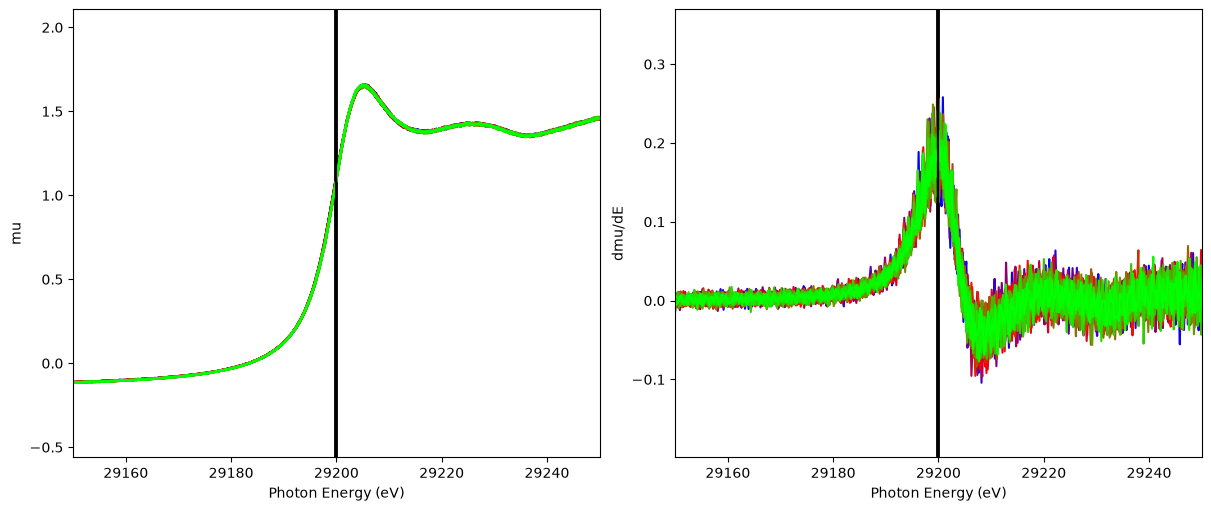

In [15]:
# Option 2b: Manual edge calibration - Check Energy Calibration with Reference Channel

my_exp.plot_XANES_spectra(emin, emax, samp_ref = 'mu Reference', spectra = 'mu', deriv = True, 
                          e0 = None, e0_line = True, 
                          ref_lines = None, overlay = True, use_legend = False, cmap_name = 'brg', 
                          filtering = False, window_length = 5, polyorder = 2)

### Find Sample E0

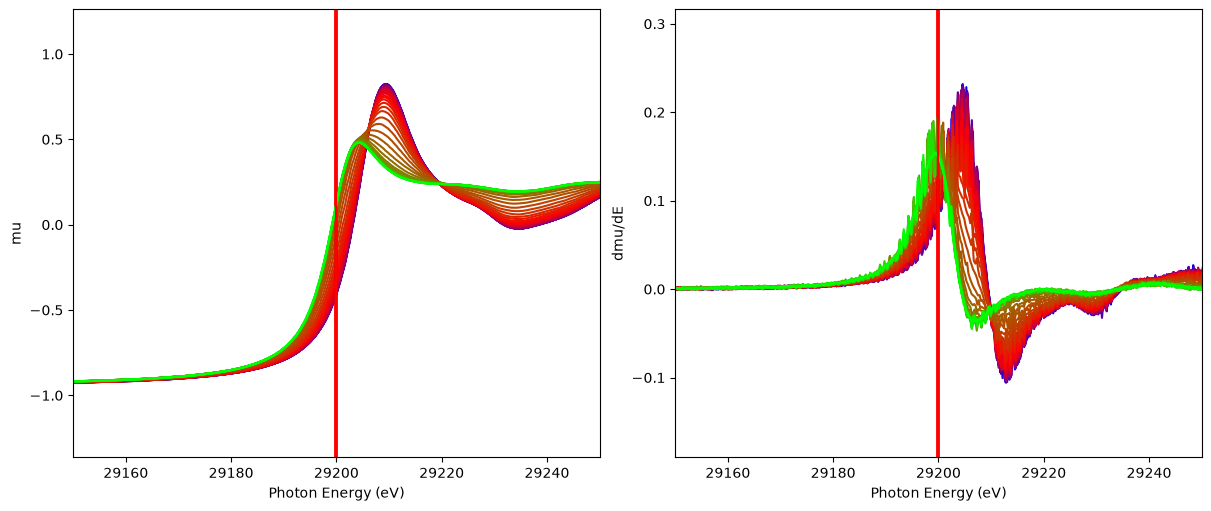

interactive(children=(FloatSlider(value=29200.0, description='ref_lines', max=29250.0, min=29150.0, step=0.05)…

<function ipywidgets.widgets.interaction._InteractFactory.__call__.<locals>.<lambda>(*args, **kwargs)>

In [16]:
# Option 2a: Manual edge finding

# Modify as needed:


# DO NOT NEED TO MODIFY BELOw
samp_ref = 'mu Sample'
spectra = 'mu'
deriv = True
e0 = None
e0_line = False 
ref_lines = (emin, emax, 0.05)
overlay = True
use_legend = False
cmap_name = 'brg'
filtering = True
window_length = 21
polyorder = 2

interact(my_exp.plot_XANES_spectra,
         emin = fixed(emin),
         emax = fixed(emax),
         samp_ref = fixed(samp_ref),
         spectra = fixed(spectra),
         deriv = fixed(deriv),
         e0 = fixed(e0),
         e0_line = fixed(e0_line),
         ref_lines = ref_lines,
         overlay = fixed(overlay),
         use_legend = fixed(use_legend),
         cmap_name = fixed(cmap_name),
         filtering = fixed(filtering),
         window_length = fixed(window_length),
         polyorder = fixed(polyorder))

In [17]:
# Option 2b: Manual edge finding - Apply  E0

# Modify as needed:

found_edge = 29201.5

# DO NOT NEED TO MODIFY BELOW

samp_edge_params = {'e0': found_edge}

# Sample
my_exp.load_params('mu Sample', samp_edge_params)

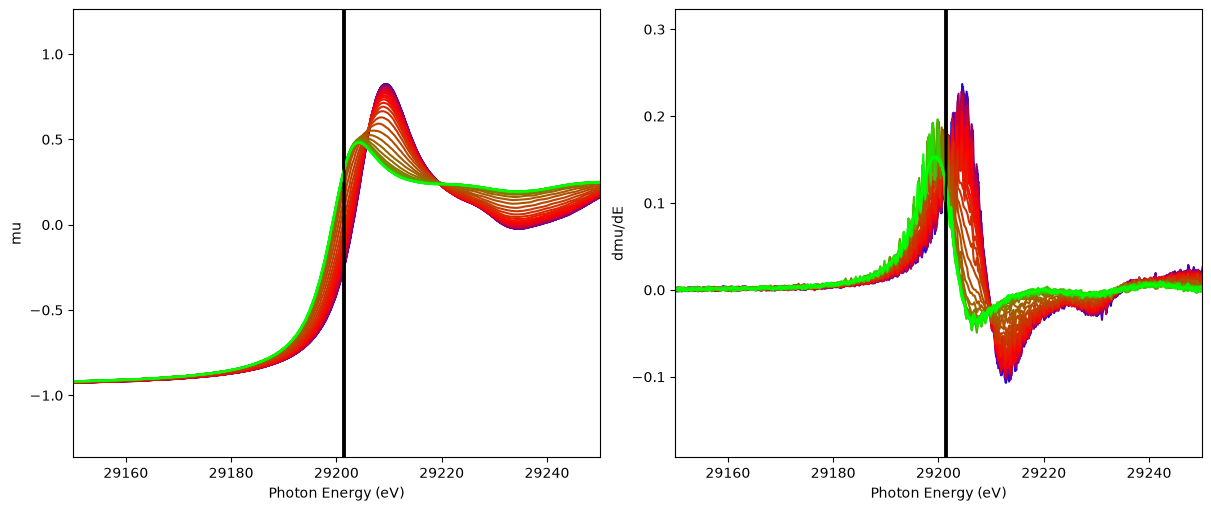

In [18]:
# Option 2b: Manual edge finding - Check Edge position of Sample Channel

my_exp.plot_XANES_spectra(emin, emax, samp_ref = 'mu Sample', spectra = 'mu', deriv = True, 
                          e0 = None, e0_line = True, 
                          ref_lines = None, overlay = True, use_legend = False, cmap_name = 'brg', 
                          filtering = True, window_length = 21, polyorder = 4)

## Step 8. Remove BL data from experimental class

In [19]:
for key in my_exp.__dict__['spectra'].keys():
    my_exp.__dict__['spectra'][key].pop('BL Data')

## Step 9. Normalize Spectra

In [20]:
# Inspect each spectrum's energy range and suggest normalization paramters

df1 = my_exp.check_Energy_Range(has_e0 = True, spectra_name = 'mu Sample', print_summary = True)

df2 = my_exp.check_Energy_Range(has_e0 = True, spectra_name = 'mu Reference', print_summary = True)

Energy Range and Energy-Step Summary for mu Sample
	Variation in starting energy points between spectra [eV]: 29004.24-29004.75
	Variation in ending energy points between spectra [eV]: 30175.00-30175.45
	Variation in step size of energy points between spectra [eV]: 0.24-0.24

Normalization Parameters for mu Sample
	Edge Energy Range [E0]: 29201.50-29201.50 eV
	Pre-edge start/stop Suggestion [pre1/pre2]: -150/-50
	Post-edge start/stop Suggestion [norm1/norm2]: 75/700
	Normalizaion order Suggestion [nnorm]: 2
	Flatten Spectra Suggestion [make_norm]: True

Energy Range and Energy-Step Summary for mu Reference
	Variation in starting energy points between spectra [eV]: 29004.24-29004.75
	Variation in ending energy points between spectra [eV]: 30175.00-30175.45
	Variation in step size of energy points between spectra [eV]: 0.24-0.24

Normalization Parameters for mu Reference
	Edge Energy Range [E0]: 29200.00-29200.00 eV
	Pre-edge start/stop Suggestion [pre1/pre2]: -150/-50
	Post-edge start/s

### Normalzie Reference Spectra

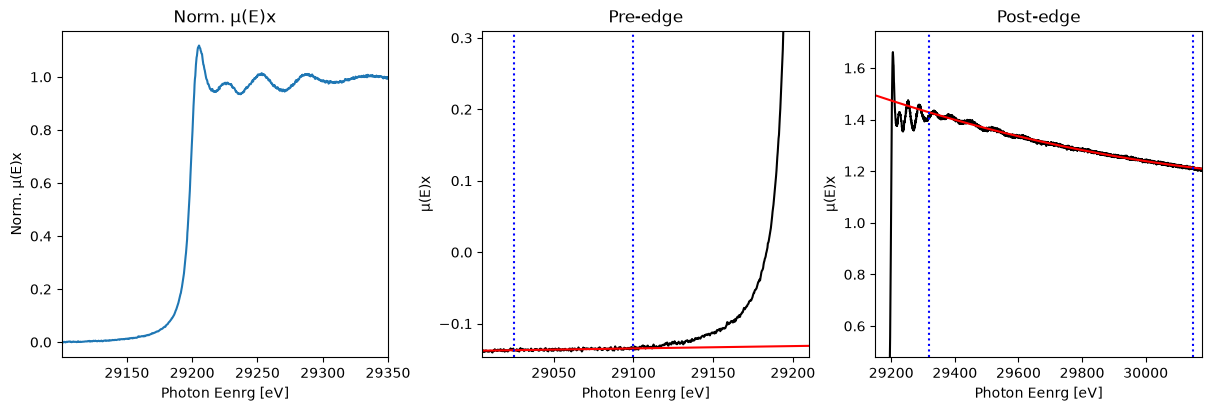

interactive(children=(Dropdown(description='larch_group', options=(<Group '20210614_SnO2_H2_TPR_Sn_EXAFS_92.tr…

<function plot.plot_NormXANES(larch_group)>

In [21]:
# Update values in the dictionary based upon summary results above

#Refernece Normalization paramters, referenced to E0
Ref_norm_params = {'pre1': -175,
                    'pre2': -100,
                    'norm1': 120,
                    'norm2': 950,
                    'nnorm': 2,
                    'make_flat': True
                   }

my_exp.load_params('mu Reference', Ref_norm_params)

my_exp.normalize_spectra('mu Reference')

# Check Normalization
R_groups = []


for key in my_exp.spectra.keys():
    R_groups.append(my_exp.spectra[key]['Absorption Spectra']['mu Reference'])
    

interact(pfcts.plot_NormXANES,
         larch_group = R_groups)

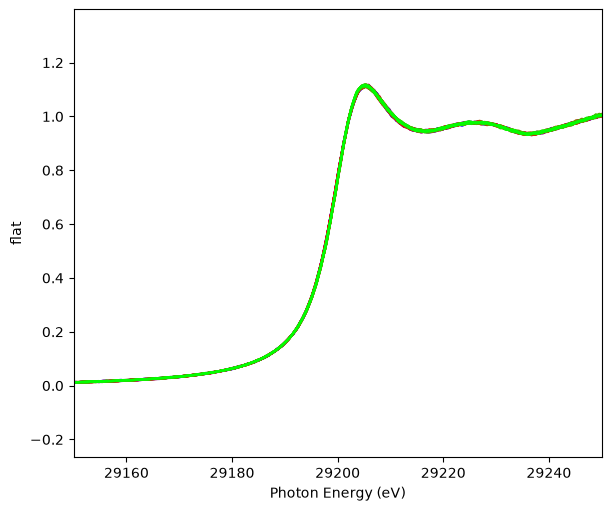

In [22]:
# Visualization of Normalized Spectra - Reference

pfcts.plot_XANES(R_groups, emin, emax, spectra = 'flat', 
                 deriv = False, e0 = None, e0_line = False, 
                 overlay = True, use_legend = False)

### Normalize Sample Spectra

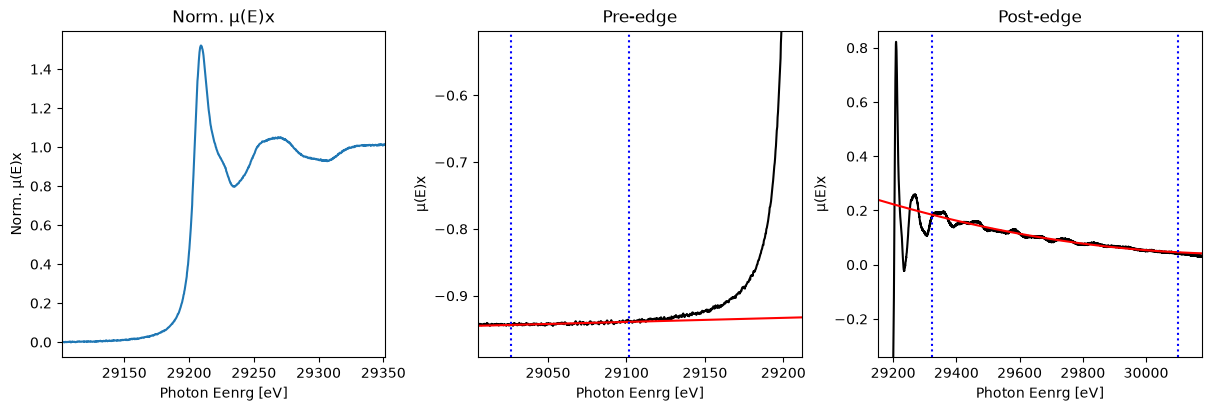

interactive(children=(Dropdown(description='larch_group', options=(<Group '20210614_SnO2_H2_TPR_Sn_EXAFS_92.tr…

<function plot.plot_NormXANES(larch_group)>

In [23]:
# Update values in the dictionary based upon summary results above

#Sample Normalization paramters, referenced to E0
Samp_norm_params = {'pre1': -175,
                    'pre2': -100,
                    'norm1': 120,
                    'norm2': 900,
                    'nnorm': 2,
                    'make_flat': True
                   }

my_exp.load_params('mu Sample', Samp_norm_params)

my_exp.normalize_spectra('mu Sample')


# Check Normalization
S_groups = []


for key in my_exp.spectra.keys():
    S_groups.append(my_exp.spectra[key]['Absorption Spectra']['mu Sample'])
    

interact(pfcts.plot_NormXANES,
         larch_group = S_groups)

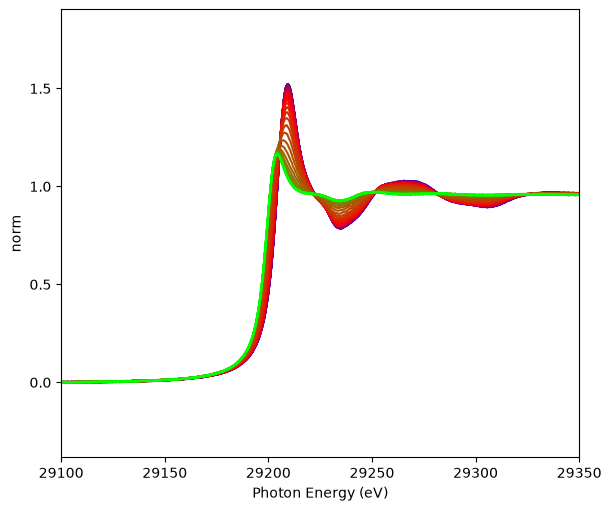

In [24]:
#. Visualization of Normalized Spectra - Sample

    
pfcts.plot_XANES(S_groups, emin-50, emax+100, spectra = 'norm', 
                 deriv = False, e0 = None, e0_line = False, 
                 overlay = True, use_legend = False)

## Step 10. Add Process Data to Experiment 

    Note: Additiona datastreams will need their own functions. Please reach out with questions.

In [25]:
# Add Mass Spec Dataset
my_exp.import_massspec(MS_filename)

# Add LabView Dataset
my_exp.import_labview(LV_filename)

# Display mass spec datafram   NOT REALLY NEEDED, good visual that it worked

my_exp.process_params['LV Data']

## Step 11. Correlate Process Parameters to XAS data

In [29]:
my_exp.correlate_process_params()

Genearted Spectra Summary
Merged Index for Process: MS Data
Non-numeric columns found!
The following columns will be dropped during interpolation:
	SV1 SP
	SV1 Feedback
	SV2 SP
	SV2 Feedback
Merged Index for Process: LV Data


In [30]:
# Visualize Correlation Table

my_exp.summary['XAS Spectra Process Params']

,File Name,TOS [s],H2,He,H2O,28,O2,Ar,CO2,T,...,Extra TC3 - Extra TC3 [°C],Extra TC4 - Extra TC4 [°C],Extra TC5 - Extra TC5 [°C],Extra TC6 - Extra TC6 [°C],Extra TC7 - Extra TC7 [°C],Extra TC8 - Extra TC8 [°C],Extra DO 1,Extra DO 2,Extra DO 3,Extra DO 4
Time,,,,,,,,,,,,,,,,,,,,,
2021-06-14 16:33:52,20210614_SnO2_H2_TPR_Sn_EXAFS_92.tra_0001,0.0,4.929417e-10,1.810452e-07,6.951219e-09,8.664734e-09,2.471646e-09,0.000004,7.719114e-11,26.120772,...,2300.190768,2300.464815,2300.464815,2300.464815,2300.343342,2300.343342,0.0,0.0,0.0,0.0
2021-06-14 16:35:37,20210614_SnO2_H2_TPR_Sn_EXAFS_92.tra_0002,105.0,4.931230e-10,1.827490e-07,6.926960e-09,8.628440e-09,2.426090e-09,0.000004,7.898010e-11,25.907800,...,2300.228154,2300.499174,2300.499174,2300.499174,2300.378966,2300.378966,0.0,0.0,0.0,0.0
2021-06-14 16:37:23,20210614_SnO2_H2_TPR_Sn_EXAFS_92.tra_0003,211.0,4.713019e-10,1.821100e-07,6.798056e-09,8.669651e-09,2.461149e-09,0.000004,7.286727e-11,26.067593,...,2300.241883,2300.510800,2300.510800,2300.510800,2300.391108,2300.391108,0.0,0.0,0.0,0.0
2021-06-14 16:39:11,20210614_SnO2_H2_TPR_Sn_EXAFS_92.tra_0004,319.0,4.056493e-09,1.949101e-07,7.054554e-09,9.396570e-09,1.122279e-08,0.000004,1.175604e-10,26.068597,...,2300.262552,2300.529460,2300.529460,2300.529460,2300.409950,2300.409950,0.0,0.0,0.0,0.0
2021-06-14 16:40:57,20210614_SnO2_H2_TPR_Sn_EXAFS_92.tra_0005,425.0,1.128710e-08,1.397490e-08,7.368780e-09,8.759550e-09,4.797820e-09,0.000004,9.577160e-11,26.015300,...,2300.294947,2300.559966,2300.559966,2300.559966,2300.440447,2300.440447,0.0,0.0,0.0,0.0
2021-06-14 16:42:42,20210614_SnO2_H2_TPR_Sn_EXAFS_92.tra_0006,530.0,1.628722e-08,7.763893e-09,7.012374e-09,8.508112e-09,3.144702e-09,0.000004,1.011230e-10,25.964397,...,2300.302634,2300.566300,2300.566300,2300.566300,2300.444244,2300.444244,0.0,0.0,0.0,0.0
2021-06-14 16:44:27,20210614_SnO2_H2_TPR_Sn_EXAFS_92.tra_0007,635.0,1.677209e-07,6.677977e-09,6.732073e-09,8.423802e-09,2.903965e-09,0.000004,9.577366e-11,26.007782,...,2300.321962,2300.584995,2300.584995,2300.584995,2300.463512,2300.463512,0.0,0.0,0.0,0.0
2021-06-14 16:46:13,20210614_SnO2_H2_TPR_Sn_EXAFS_92.tra_0008,741.0,5.390002e-07,6.013107e-09,6.438386e-09,8.409555e-09,2.787266e-09,0.000004,8.044948e-11,25.961600,...,2300.348302,2300.611476,2300.611476,2300.611476,2300.491137,2300.491137,0.0,0.0,0.0,0.0
2021-06-14 16:47:59,20210614_SnO2_H2_TPR_Sn_EXAFS_92.tra_0009,847.0,5.453353e-07,5.441864e-09,6.127758e-09,8.365563e-09,2.705257e-09,0.000004,8.813759e-11,26.992001,...,2300.356767,2300.619987,2300.619987,2300.619987,2300.500101,2300.500101,0.0,0.0,0.0,0.0


## Step 12. Perform LCF

### Generate list of basis spectra groups

In [31]:
first_scan = list(my_exp.spectra.keys())[0]

middle_scan = list(my_exp.spectra.keys())[30]

last_scan = list(my_exp.spectra.keys())[-1]

print(f'First Scan Name: {first_scan}')
print(f'Middle Scan Name: {middle_scan}')
print(f'Last Scan Name: {last_scan}')

First Scan Name: 20210614_SnO2_H2_TPR_Sn_EXAFS_92.tra_0001
Middle Scan Name: 20210614_SnO2_H2_TPR_Sn_EXAFS_92.tra_0031
Last Scan Name: 20210614_SnO2_H2_TPR_Sn_EXAFS_92.tra_0050


In [32]:
# Basis set made from three spectra in the sample dataset
basis1 = my_exp.spectra[first_scan]['Absorption Spectra']['mu Sample'] 
basis1.name = first_scan

basis2 = my_exp.spectra[middle_scan]['Absorption Spectra']['mu Sample']
basis2.name = middle_scan

basis3 = my_exp.spectra[last_scan]['Absorption Spectra']['mu Sample']
basis3.name = last_scan

basis = [basis1, basis2, basis3]

### Load basis set into a "Fit"

In [33]:
# Load list of basis spectra into the experiment
fit_name = 'Fit 2'
my_exp.load_lcf_basis(basis, fit_name)

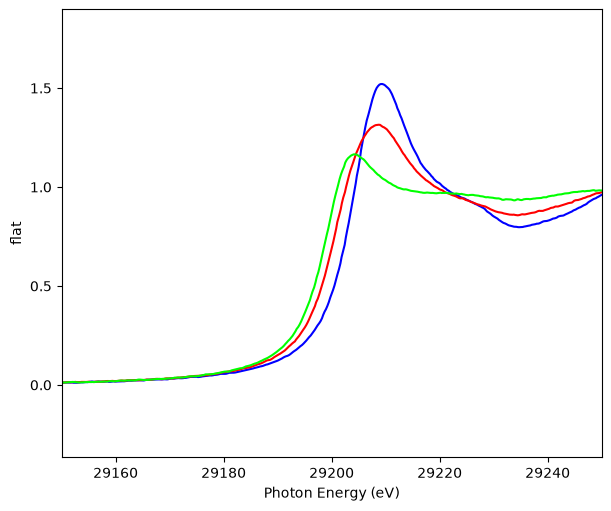

In [34]:
# Visualize basis sets for fitting

basis_groups = my_exp.analysis['LCF'][fit_name]['basis spectra']

pfcts.plot_XANES(basis_groups, emin, emax, spectra = 'flat', 
                 deriv = False, e0 = None, e0_line = False, 
                 overlay = True, use_legend = False)

### Perform LCF

In [35]:
# Fit the sample spectra
emin_fit = Edge_Energy-50
emax_fit = Edge_Energy+50
minvals = 0
maxvals = 1
array_name = 'flat'
sum_to_one = False

my_exp.fit_LCF(fit_name, emin_fit, emax_fit, 
               weights = None, minvals = minvals, maxvals = maxvals, 
               arrayname = array_name, sum_to_one = sum_to_one)

### Generate a Fit Report

In [36]:
# Generate fit report for all spectra

my_exp.lcf_report(fit_name)

# Contents of the Fit Summary
my_exp.analysis['LCF'][fit_name]['Fit Summary']

### Visualize Fit and Errors with one Process Parameter

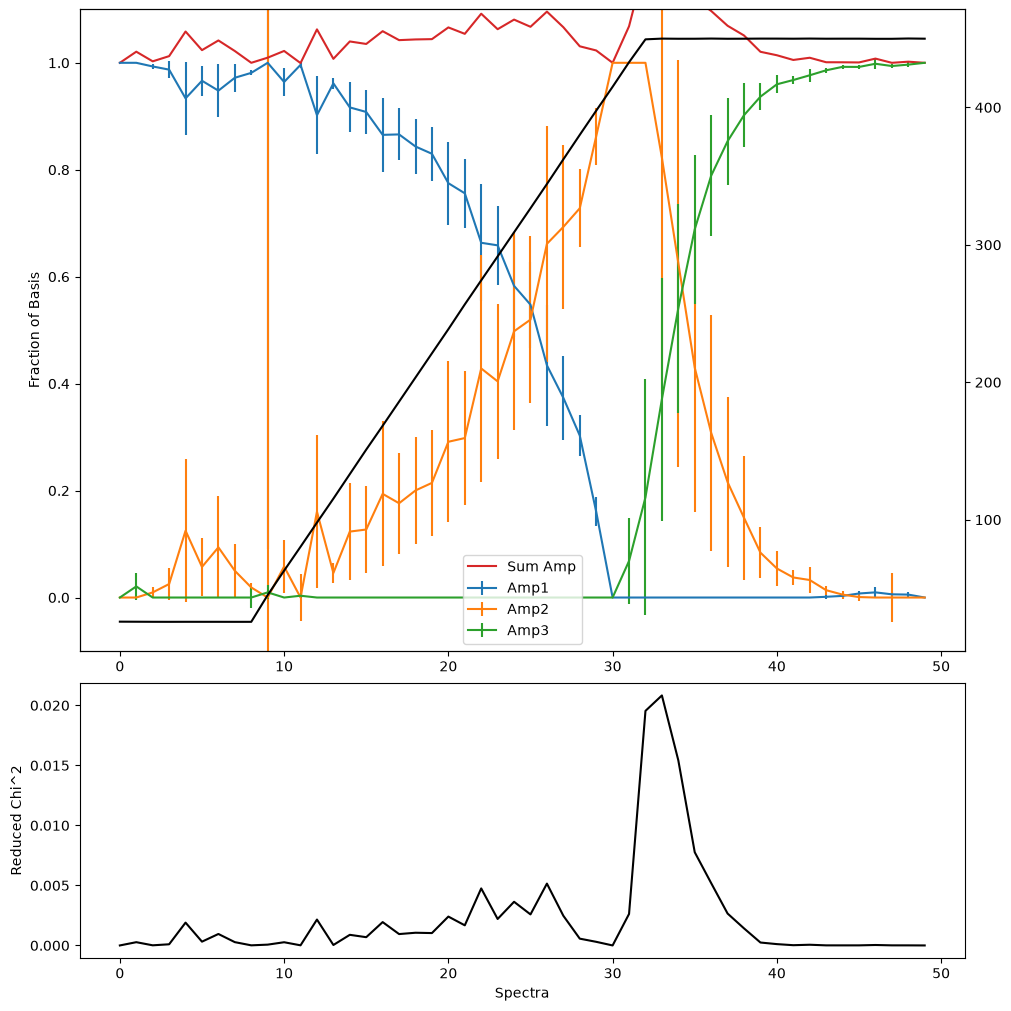

In [38]:
# Visualize Fit with process parameter

process_param = 'TR1 T [°C]'

my_exp.plot_LCF_results(fit_name, process_parameter = process_param)

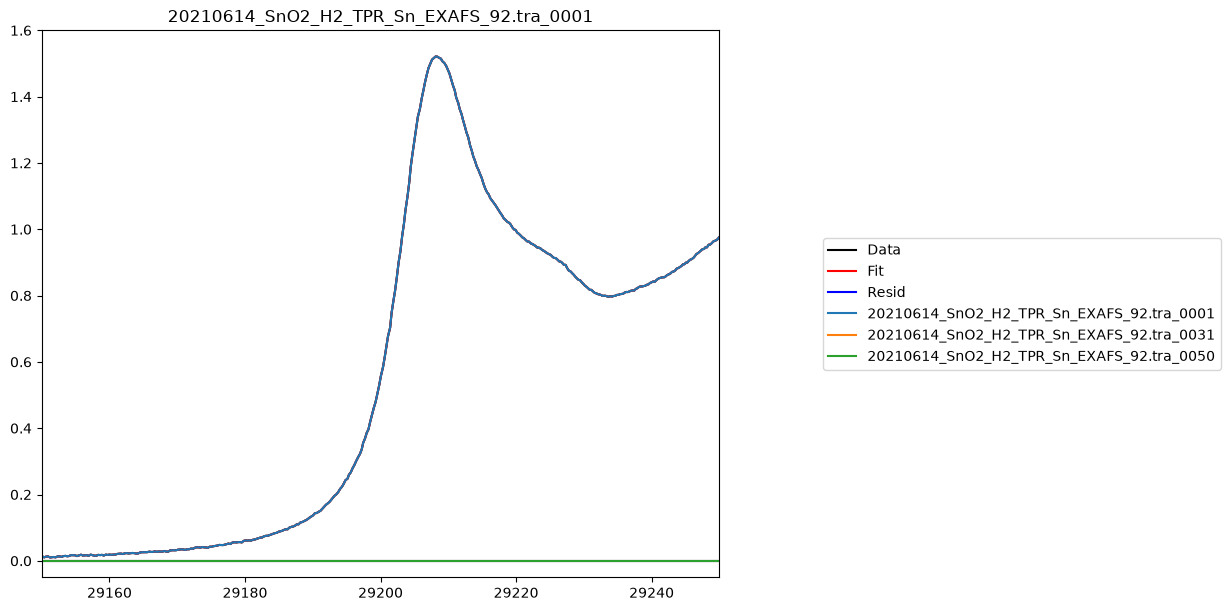

interactive(children=(Dropdown(description='spectra', options=('20210614_SnO2_H2_TPR_Sn_EXAFS_92.tra_0001', '2…

<function ipywidgets.widgets.interaction._InteractFactory.__call__.<locals>.<lambda>(*args, **kwargs)>

In [39]:
# Visualize individual fits

ymin = -0.05
ymax = 1.6


interact(my_exp.plot_LCF, spectra = my_exp.spectra.keys(),
        fit_name = fixed(fit_name),
        emin = fixed(emin), emax = fixed(emax), 
        ymin = fixed(ymin), ymax = fixed(ymax))

## 13. Export Data

### XAS-process parameter correlation table

In [40]:
# Save Correlation Dataframe

my_exp.save_processparams(os.path.join(output_dir,fname_correlation))

Process Parameter Data Saved


### LCF fitting results

In [41]:
my_exp.save_lcf_results(os.path.join(output_dir,exp_name+'_LCF_'+fit_name), 
                        fit_name, save_spectra = True)

Directory Already Exists - Continuing Program
LCF Data Saved


### Interpolated XAS spectra (XANES)

In [42]:
df = my_exp.check_Energy_Range(has_e0 = False, spectra_name = 'mu Sample', print_summary = True)

Energy Range and Energy-Step Summary for mu Sample
	Variation in starting energy points between spectra [eV]: 29004.24-29004.75
	Variation in ending energy points between spectra [eV]: 30175.00-30175.45
	Variation in step size of energy points between spectra [eV]: 0.24-0.24



### Perform the interpolation based upon start/stop/step size

In [43]:
# Set the energy range and step size to interpolate onto
start = 29050
stop = 29450
step = 0.25

In [44]:
# Interpolate Spectra
my_exp.interpolate_spectra_E(start, stop, step, sample = 'mu Sample', mu = 'flat')

In [45]:
my_exp.__dict__['summary']['Interpolated energy']

,2021-06-14 16:33:52,2021-06-14 16:35:37,2021-06-14 16:37:23,2021-06-14 16:39:11,2021-06-14 16:40:57,2021-06-14 16:42:42,2021-06-14 16:44:27,2021-06-14 16:46:13,2021-06-14 16:47:59,2021-06-14 16:49:44,...,2021-06-14 17:44:29,2021-06-14 17:46:15,2021-06-14 17:48:01,2021-06-14 17:49:47,2021-06-14 17:51:32,2021-06-14 17:53:18,2021-06-14 17:55:04,2021-06-14 17:56:50,2021-06-14 17:58:36,2021-06-14 18:00:22
energy,,,,,,,,,,,,,,,,,,,,,
29050.00,0.001013,0.001464,-0.000742,0.001312,0.000055,-0.000932,-0.000377,0.000122,-0.000019,-0.003466,...,-0.000160,-0.000063,-0.000196,0.001247,-0.000188,0.001070,0.000792,0.000043,0.000610,-0.000917
29050.25,0.000376,0.000871,0.000069,0.001016,-0.000150,-0.001876,0.000931,0.000237,-0.001251,-0.001532,...,-0.000681,-0.000773,-0.000982,-0.000483,-0.000235,0.001030,-0.000195,0.000704,-0.000738,-0.000979
29050.50,-0.000205,0.000235,0.000406,0.000116,0.000748,-0.001988,0.000362,-0.000220,-0.001720,0.001406,...,0.000422,-0.000114,-0.001248,-0.000497,-0.001423,0.000076,0.000143,-0.000519,-0.000650,-0.000403
29050.75,0.000544,-0.000962,0.001027,0.000197,-0.001169,-0.001150,0.001701,0.000442,-0.001620,0.000002,...,0.000494,0.000121,0.000855,-0.001067,-0.001005,-0.000312,-0.000704,-0.001056,-0.000455,-0.000103
29051.00,-0.000170,-0.000603,0.000383,0.000942,-0.001080,-0.000598,0.000591,-0.000059,-0.001501,-0.000846,...,-0.000562,0.000576,0.000750,-0.001747,-0.000243,0.000298,-0.000938,0.000057,-0.000309,-0.000029
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29449.00,1.005361,1.006933,1.003642,1.005937,1.008080,1.008404,1.005449,1.004983,1.005073,1.004691,...,1.000109,1.002335,1.002481,1.002281,1.003452,1.000690,1.002550,1.002287,1.001444,1.000542
29449.25,1.004610,1.003220,1.005551,1.006603,1.005807,1.004014,1.006222,1.006607,1.004690,1.004913,...,1.002850,1.001662,1.003829,1.000519,1.002497,1.000663,1.003476,1.000444,1.001362,1.002299
29449.50,1.006487,1.006576,1.007906,1.006715,1.005787,1.004552,1.006451,1.006209,1.004825,1.005510,...,1.002146,1.002803,1.002897,1.000951,1.002041,1.003442,1.003446,1.003677,1.003524,1.003793


<Axes: xlabel='energy'>

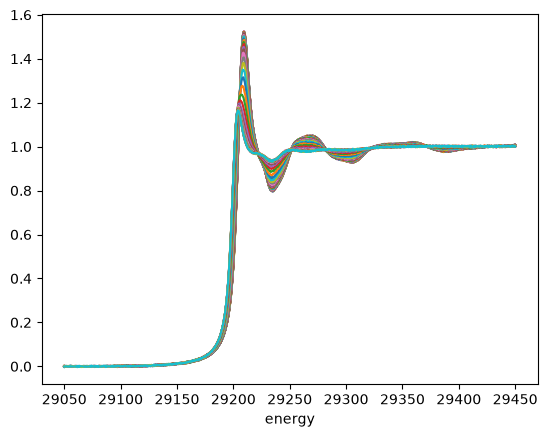

In [46]:
# Visualzie interpolated spectra with plot

my_exp.__dict__['summary']['Interpolated energy'].plot(legend=False)

### Save interpoalted XAS data

In [47]:
# Save Normalized XANES:

my_exp.save_interpXAS(os.path.join(output_dir,fname_interpXAS))

Interpolated Data Saved


## Step 14. Save Experiment with 'pickle'

In [48]:
pickle_path = os.path.join(pickle_dir,pickle_name)

pickle_out = open(pickle_path,"wb")
pickle.dump(my_exp, pickle_out)
pickle_out.close()